# SILVA Physics-Guided Diffusion for PDEs

This lab derives inference-time residual guidance, Gaussian smoothing, hard
boundary projection, and deterministic/stochastic reverse paths. It solves a
compact Poisson field from random initialization and maps the same interface to
the source Poisson, diffusion, and Burgers studies [[64]](https://jseluis.github.io/silva-networks/paper/references/#ref-64).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[32]](https://jseluis.github.io/silva-networks/paper/references/#ref-32), [[64]](https://jseluis.github.io/silva-networks/paper/references/#ref-64). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from silva_networks import (
    SILVAPhysicsGuidedDiffusionPDE,
    finite_difference_poisson_energy,
    make_poisson_diffusion_dataset,
    project_homogeneous_dirichlet,
)

## 1. Residual Energy

For $-\Delta u=f$ with hard boundary conditions,

$$E(u)=\frac12\lVert-\Delta_hu-f\rVert_2^2.$$

The general implementation accepts any differentiable
$E_{PDE}(u)=\frac12\lVert\mathcal Lu+\mathcal N(u)-f\rVert_2^2$ and an
independent boundary projector.

In [3]:
data = make_poisson_diffusion_dataset(size=12, seed=33)

def energy(field, forcing):
    return finite_difference_poisson_energy(field, forcing, data.spacing)

initial = project_homogeneous_dirichlet(data.initial)
print("initial residual energy:", float(energy(initial, data.forcing)))
print("target residual energy:", float(energy(data.target, data.forcing)))

initial residual energy: 140655.40625
target residual energy: 0.0027077794075012207


## 2. Reverse Step

$$\widetilde u_t=\operatorname{Prior}(u_t,t),$$

$$\bar u_t=G_\sigma*\widetilde u_t,$$

$$u_{t-1}=\mathcal B(\bar u_t-\eta\nabla E(\bar u_t)+\xi_t).$$

The neutral prior below isolates the physical correction. Replacing it with a
trained noise predictor changes no energy or boundary code.

In [4]:
sampler = SILVAPhysicsGuidedDiffusionPDE(
    energy,
    project_homogeneous_dirichlet,
    steps=45,
    guidance_step=7e-6,
    prior_strength=0.0,
    smoothing_sigma=0.55,
)
result = sampler(initial, condition=data.forcing, return_result=True)
print("initial/final energy:", float(energy(initial, data.forcing)), result.energies[-1])
print("reverse states:", len(result.states))
assert result.energies[-1] < float(energy(initial, data.forcing))
assert torch.count_nonzero(result.output[..., 0, :]) == 0

initial/final energy: 140655.40625 73.91302490234375
reverse states: 46


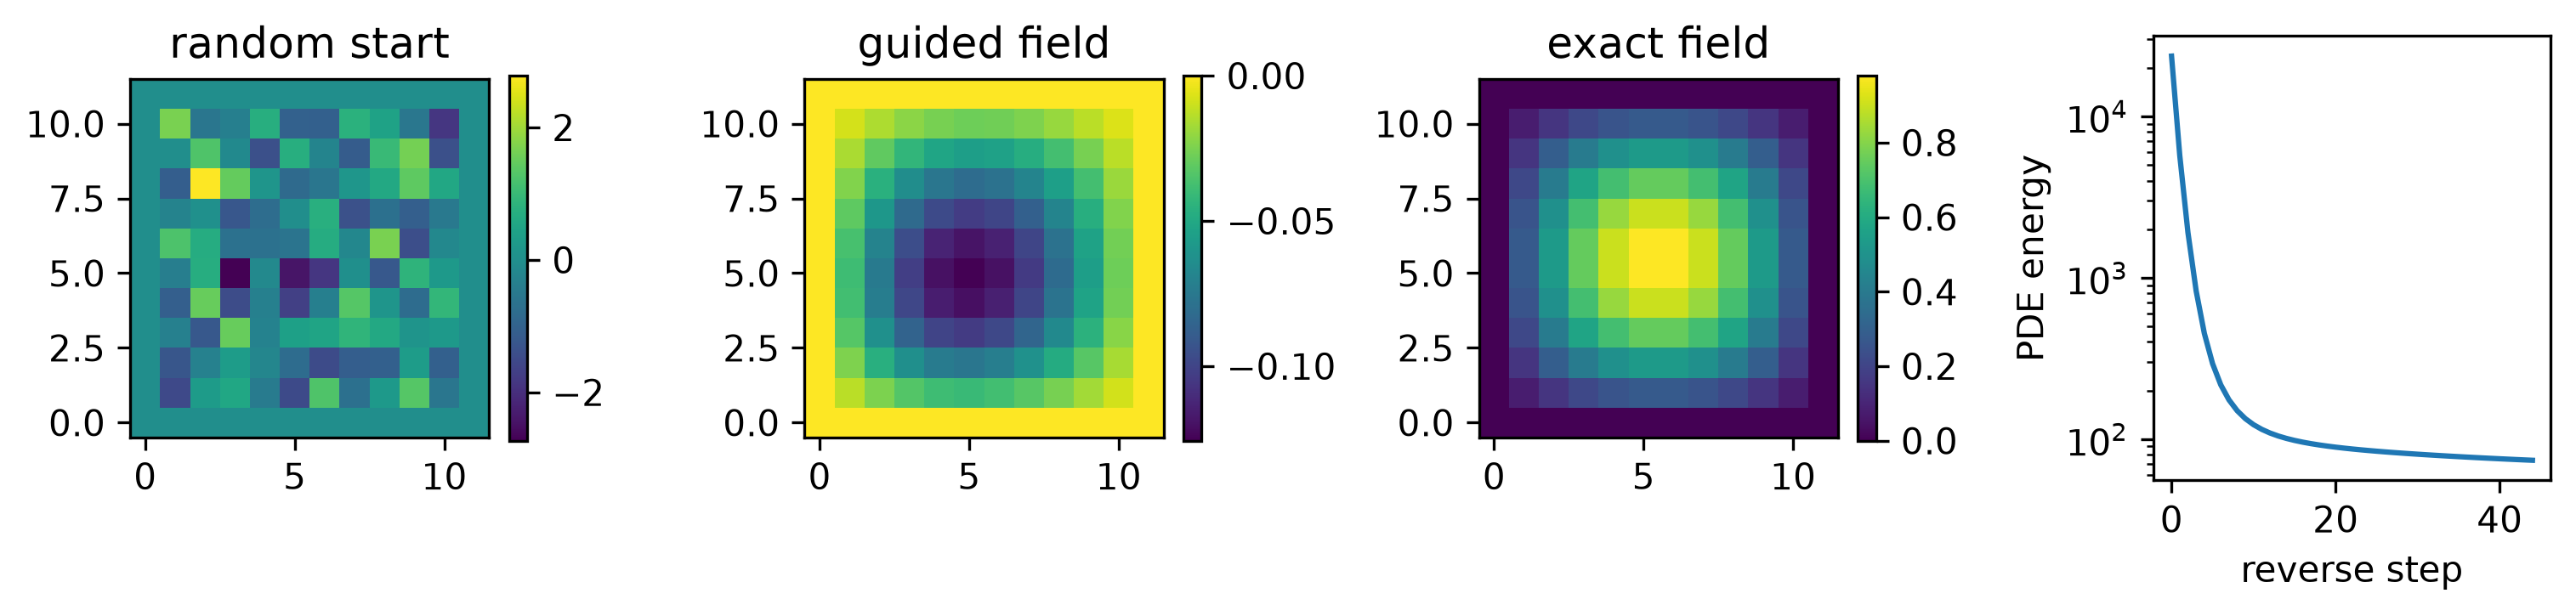

In [5]:
figure, axes = plt.subplots(1, 4, figsize=(10.2, 2.5))
fields = [initial[0, 0], result.output.detach()[0, 0], data.target[0, 0]]
titles = ["random start", "guided field", "exact field"]
for axis, values, title in zip(axes[:3], fields, titles):
    image = axis.imshow(values, origin="lower", cmap="viridis")
    axis.set_title(title)
    figure.colorbar(image, ax=axis, fraction=0.046)
axes[3].semilogy(result.energies)
axes[3].set(xlabel="reverse step", ylabel="PDE energy")
figure.tight_layout()
plt.show()

## 3. Prior Independence and Stochasticity

`noise_predictor(state, time, condition)` may be a U-Net, neural operator, or
other field prior trained without the target equation. `prior_mode="noise"`
uses a DDPM-style clean estimate; `prior_mode="clean"` accepts a direct field
estimate. Set `stochastic=True` to add scheduled perturbations. Always report
both residual-energy and boundary traces: a visually plausible field is not a
PDE solution unless those diagnostics agree.

## 4. Source-Scale Route

Generate or obtain the source 64x64 fields and preserve the reported 4,000
snapshot split, global max-absolute normalization, three-level 64-channel
prior, linear variance schedule, and equation-specific guidance steps. A scalar
float32 array of 4,000 x 64 x 64 values is about 66 MB before conditions,
time fields, metadata, and checkpoints. For transient diffusion and Burgers,
treat physical time as an additional grid axis, hard-project the initial and
spatial boundaries after every reverse step, and report relative field error,
PDE residual, boundary error, convergence, and coefficient-shift tests.

## Source Data and Full Experiment Preflight

The source fields are procedurally generated [[64]](https://jseluis.github.io/silva-networks/paper/references/#ref-64). Validate 64-256 small fields and a frozen prior first, then recreate the 4,000-field 64-by-64 coefficient, boundary, normalization, and reverse-schedule protocol.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [6]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_physics_guided_diffusion_pde')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://arxiv.org/abs/2604.01242
access:
 - The cited article specifies generated Poisson, diffusion, and Burgers fields rather than an external observational dataset.
 - Regenerate coefficient, initial, and boundary distributions and record the numerical solver, grid, time step, normalization, and seed.
storage:
 - A scalar float32 set of 4,000 fields at 64x64 is about 62.5 MiB; conditioning and trajectories multiply that amount.
 - Store prior-training fields, normalization, PDE parameters, and reverse-inference traces in separate shards.
source-scale steps:
 1. Generate the source 64x64 Poisson, diffusion, or Burgers fields and reproduce global max-absolute normalization.
 2. Train the three-level field prior independently of the PDE residual and freeze its checkpoint.
 3. Run deterministic and stochastic guided reverse schedules with Gaussian smoothing and hard boundary projection, then report field, residual, and boundary errors.


## From 33 Silva Physics Guided Diffusion Pde to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | a sampled solution field on a grid or mesh |
| Condition | coefficient, forcing, boundary, and coordinate fields |
| Repeated computation | a tied local/spectral/operator field with source reinjection |
| Required invariants | spatial shape, boundary conditions, and resolution semantics |
| Replaceable components | lifting map, spectral/local operator, physics field, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace Prior, Physics Energy, Smoother, and Boundary Projection

```python
sampler = SILVAPhysicsGuidedDiffusionPDE(
    noise_predictor=my_pretrained_prior,
    energy=my_pde_residual_energy,
    boundary_projection=my_boundary_projection,
    smoother=my_gaussian_smoother,
    schedule=my_reverse_schedule,
)
```

The prior is trained independently of the governing equation. During
inference, each reverse step denoises, smooths, differentiates the PDE energy,
and projects the boundary. Full experiments should archive the prior
checkpoint, coefficient shifts, guidance schedule, random seeds, and every PDE
and boundary residual.


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**solution error, PDE residual, boundary error, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **resolution, retained modes, channels, domain size, and dataset size**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '33_silva_physics_guided_diffusion_pde.ipynb',
    "state": 'a sampled solution field on a grid or mesh',
    "condition": 'coefficient, forcing, boundary, and coordinate fields',
    "transition": 'a tied local/spectral/operator field with source reinjection',
    "invariants": 'spatial shape, boundary conditions, and resolution semantics',
    "compact_metric": 'solution error, PDE residual, boundary error, and fixed-point residual',
    "scale_axis": 'resolution, retained modes, channels, domain size, and dataset size',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '33_silva_physics_guided_diffusion_pde.ipynb',
 'state': 'a sampled solution field on a grid or mesh',
 'condition': 'coefficient, forcing, boundary, and coordinate fields',
 'transition': 'a tied local/spectral/operator field with source reinjection',
 'invariants': 'spatial shape, boundary conditions, and resolution semantics',
 'compact_metric': 'solution error, PDE residual, boundary error, and fixed-point residual',
 'scale_axis': 'resolution, retained modes, channels, domain size, and dataset size'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **operator feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **a sampled solution field on a grid or mesh**, and its repeated map,
**a tied local/spectral/operator field with source reinjection**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [9]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('operator feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


operator feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


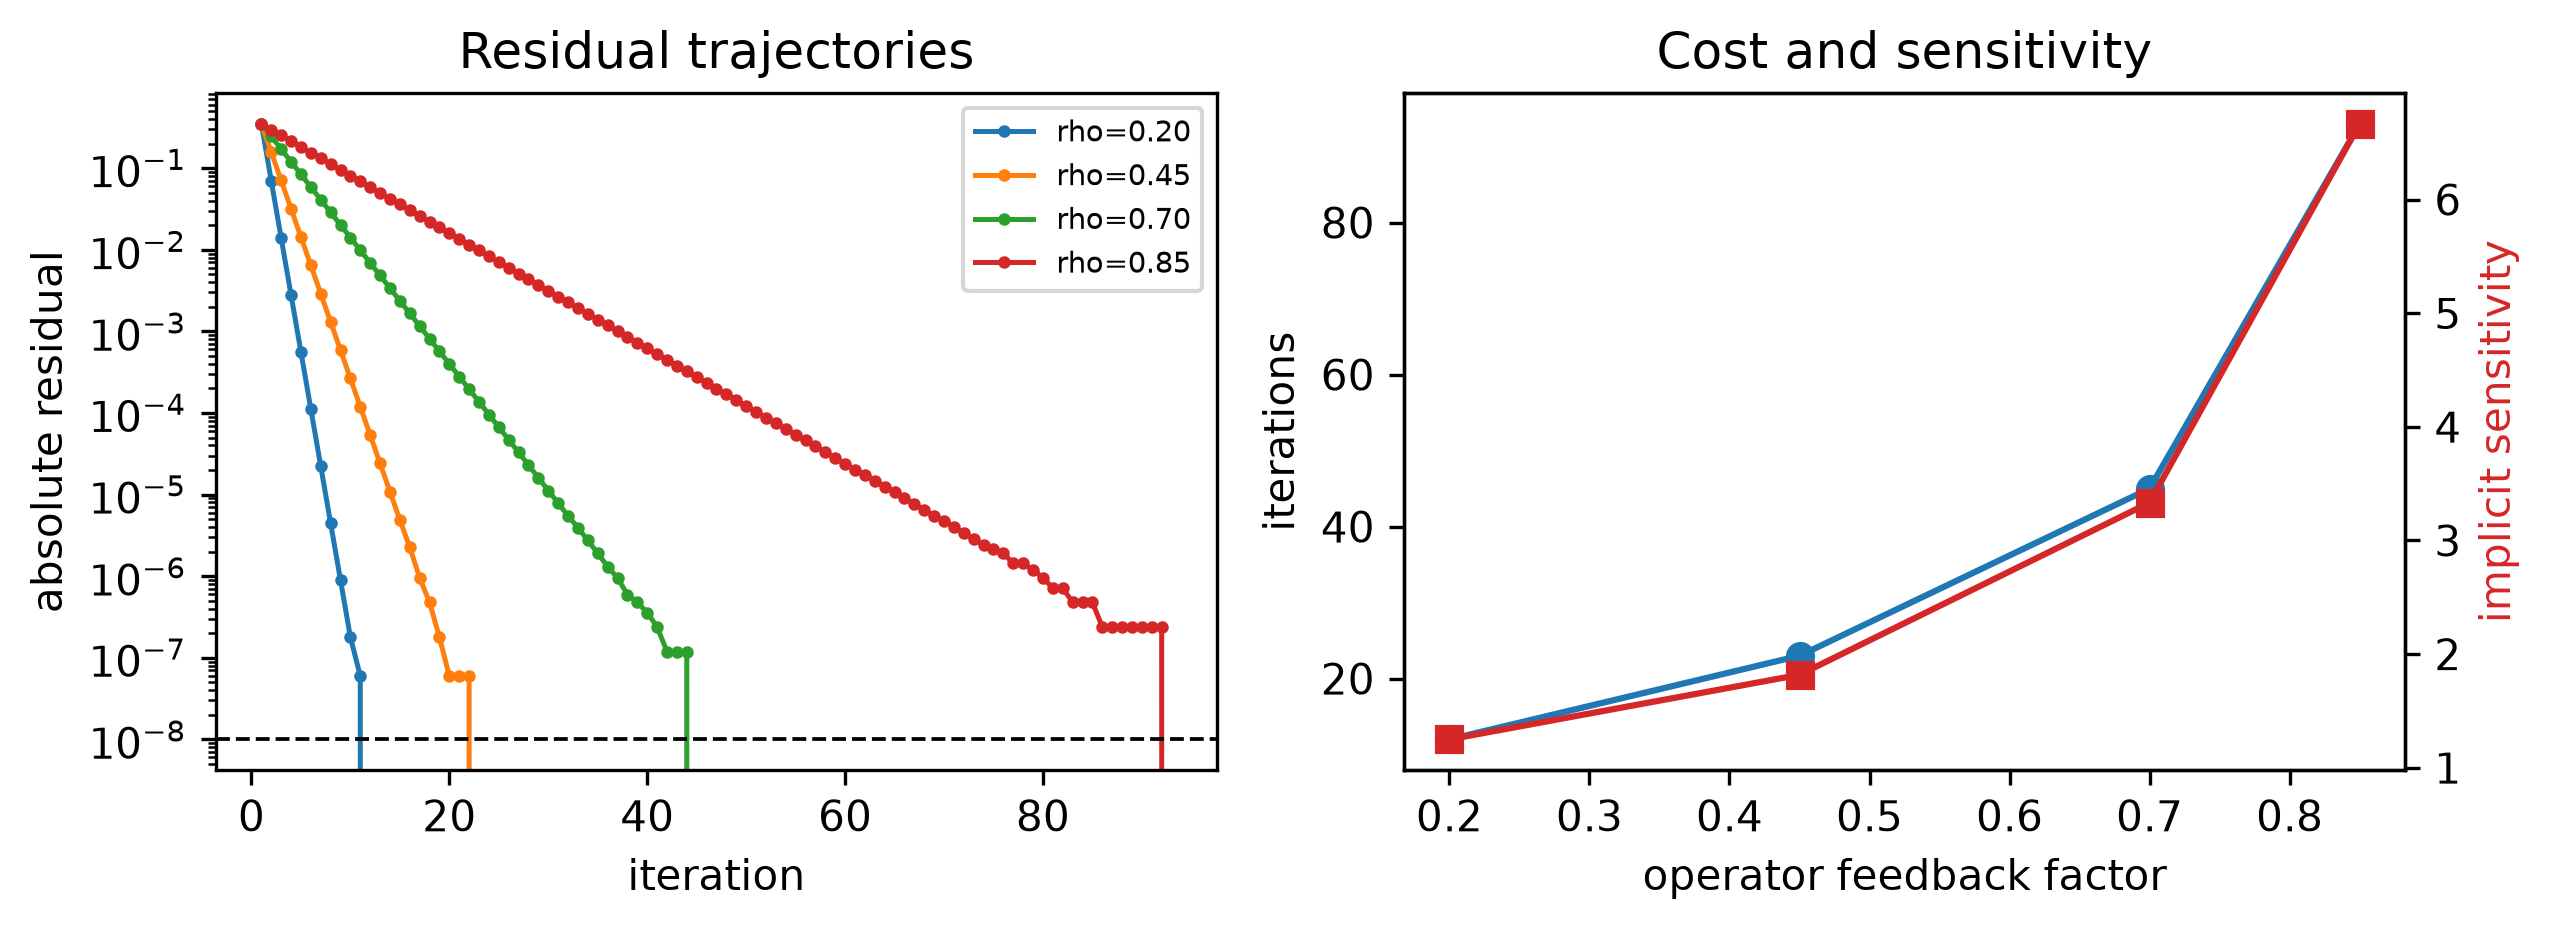

In [10]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('operator feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the operator feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | solution error, PDE residual, boundary error, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | spatial shape, boundary conditions, and resolution semantics |
| Scale sweep | Change one of resolution, retained modes, channels, domain size, and dataset size at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How do reverse diffusion and PDE-energy guidance compose? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#physics-guided-diffusion-pde-solver) |
| Which sampler and replaceable physics hooks are public? | [Emerging Equilibria API](https://jseluis.github.io/silva-networks/api/emerging_equilibria/) |
| Which exact Poisson field supplies the compact simulation? | [Emerging Data API](https://jseluis.github.io/silva-networks/api/emerging_data/) |
